In [76]:
%config InlineBackend.figure_format = 'retina'

In [ ]:
import scanpy as sc
import glob
from glob import glob
import pandas as pd
import seaborn as sns
import os
from collections import defaultdict
import numpy as np
import sys
import matplotlib.pyplot as plt
import warnings
from scipy.stats import norm
from adjustText import adjust_text
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [6, 6]
plt.rcParams['figure.dpi'] = 200

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

In [87]:
adata = sc.read_h5ad(
    '/tmp/xenium_skin.h5ad'
)

In [88]:
adata

AnnData object with n_obs × n_vars = 29569 × 2813
    obs: 'cell_id', 'transcript_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'sample_id', 'batch', 'n_counts', 'n_genes', 'celltype_scanvi', 'n_genes_by_counts', 'celltype_scanvi_ManUpdated', 'treatment', 'cell_type', 'cell_type_int'
    var: 'symbol', 'isin_top1000_var_mean_genes', 'isin_TFdict_targets', 'isin_TFdict_regulators'
    uns: 'cell_type_colors', 'log1p'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'imputed_count', 'normalized_count', 'raw_count'

In [89]:
adata.obs[['sample_id', 'treatment']].value_counts()

sample_id  treatment        
sample15   48/80                11940
sample16   UT                   10660
sample12   Topical capsaicin     6969
Name: count, dtype: int64

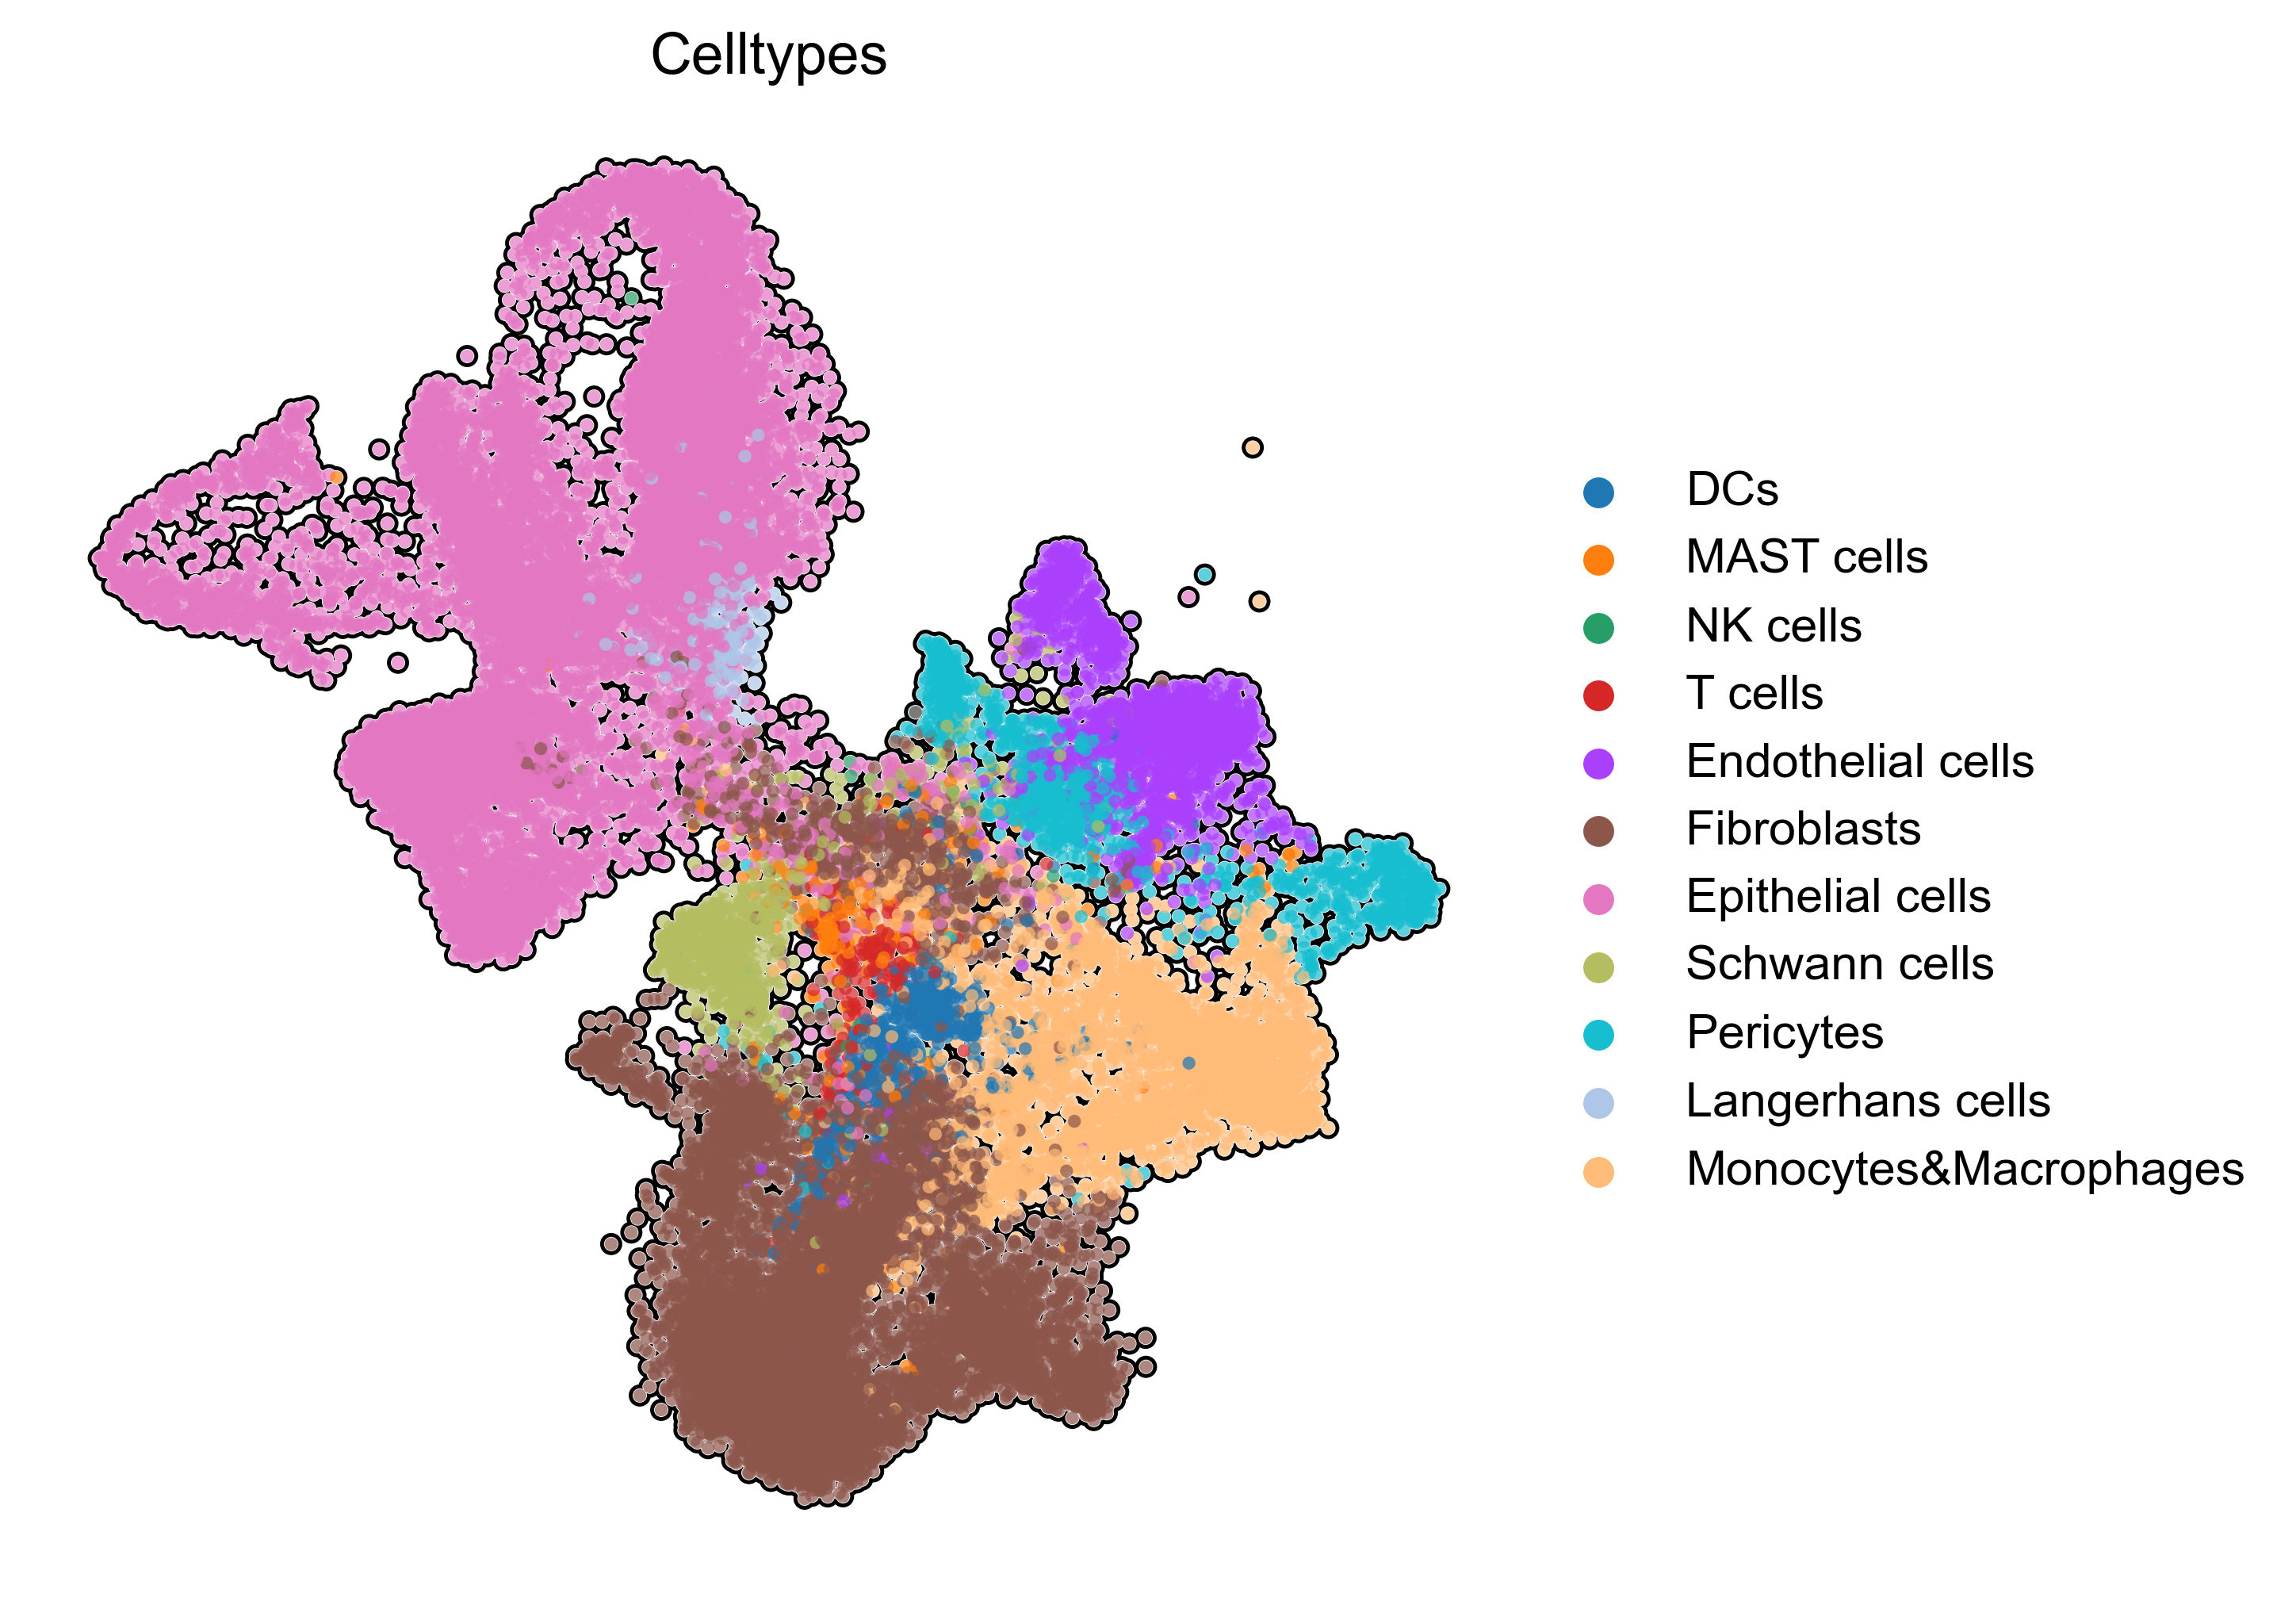

In [96]:
sc.pl.umap(
    adata, 
    color=['celltype_scanvi_ManUpdated'], 
    ncols = 1, 
    add_outline=True,
    s=35,
    frameon=False,  
    title='Celltypes'  
)

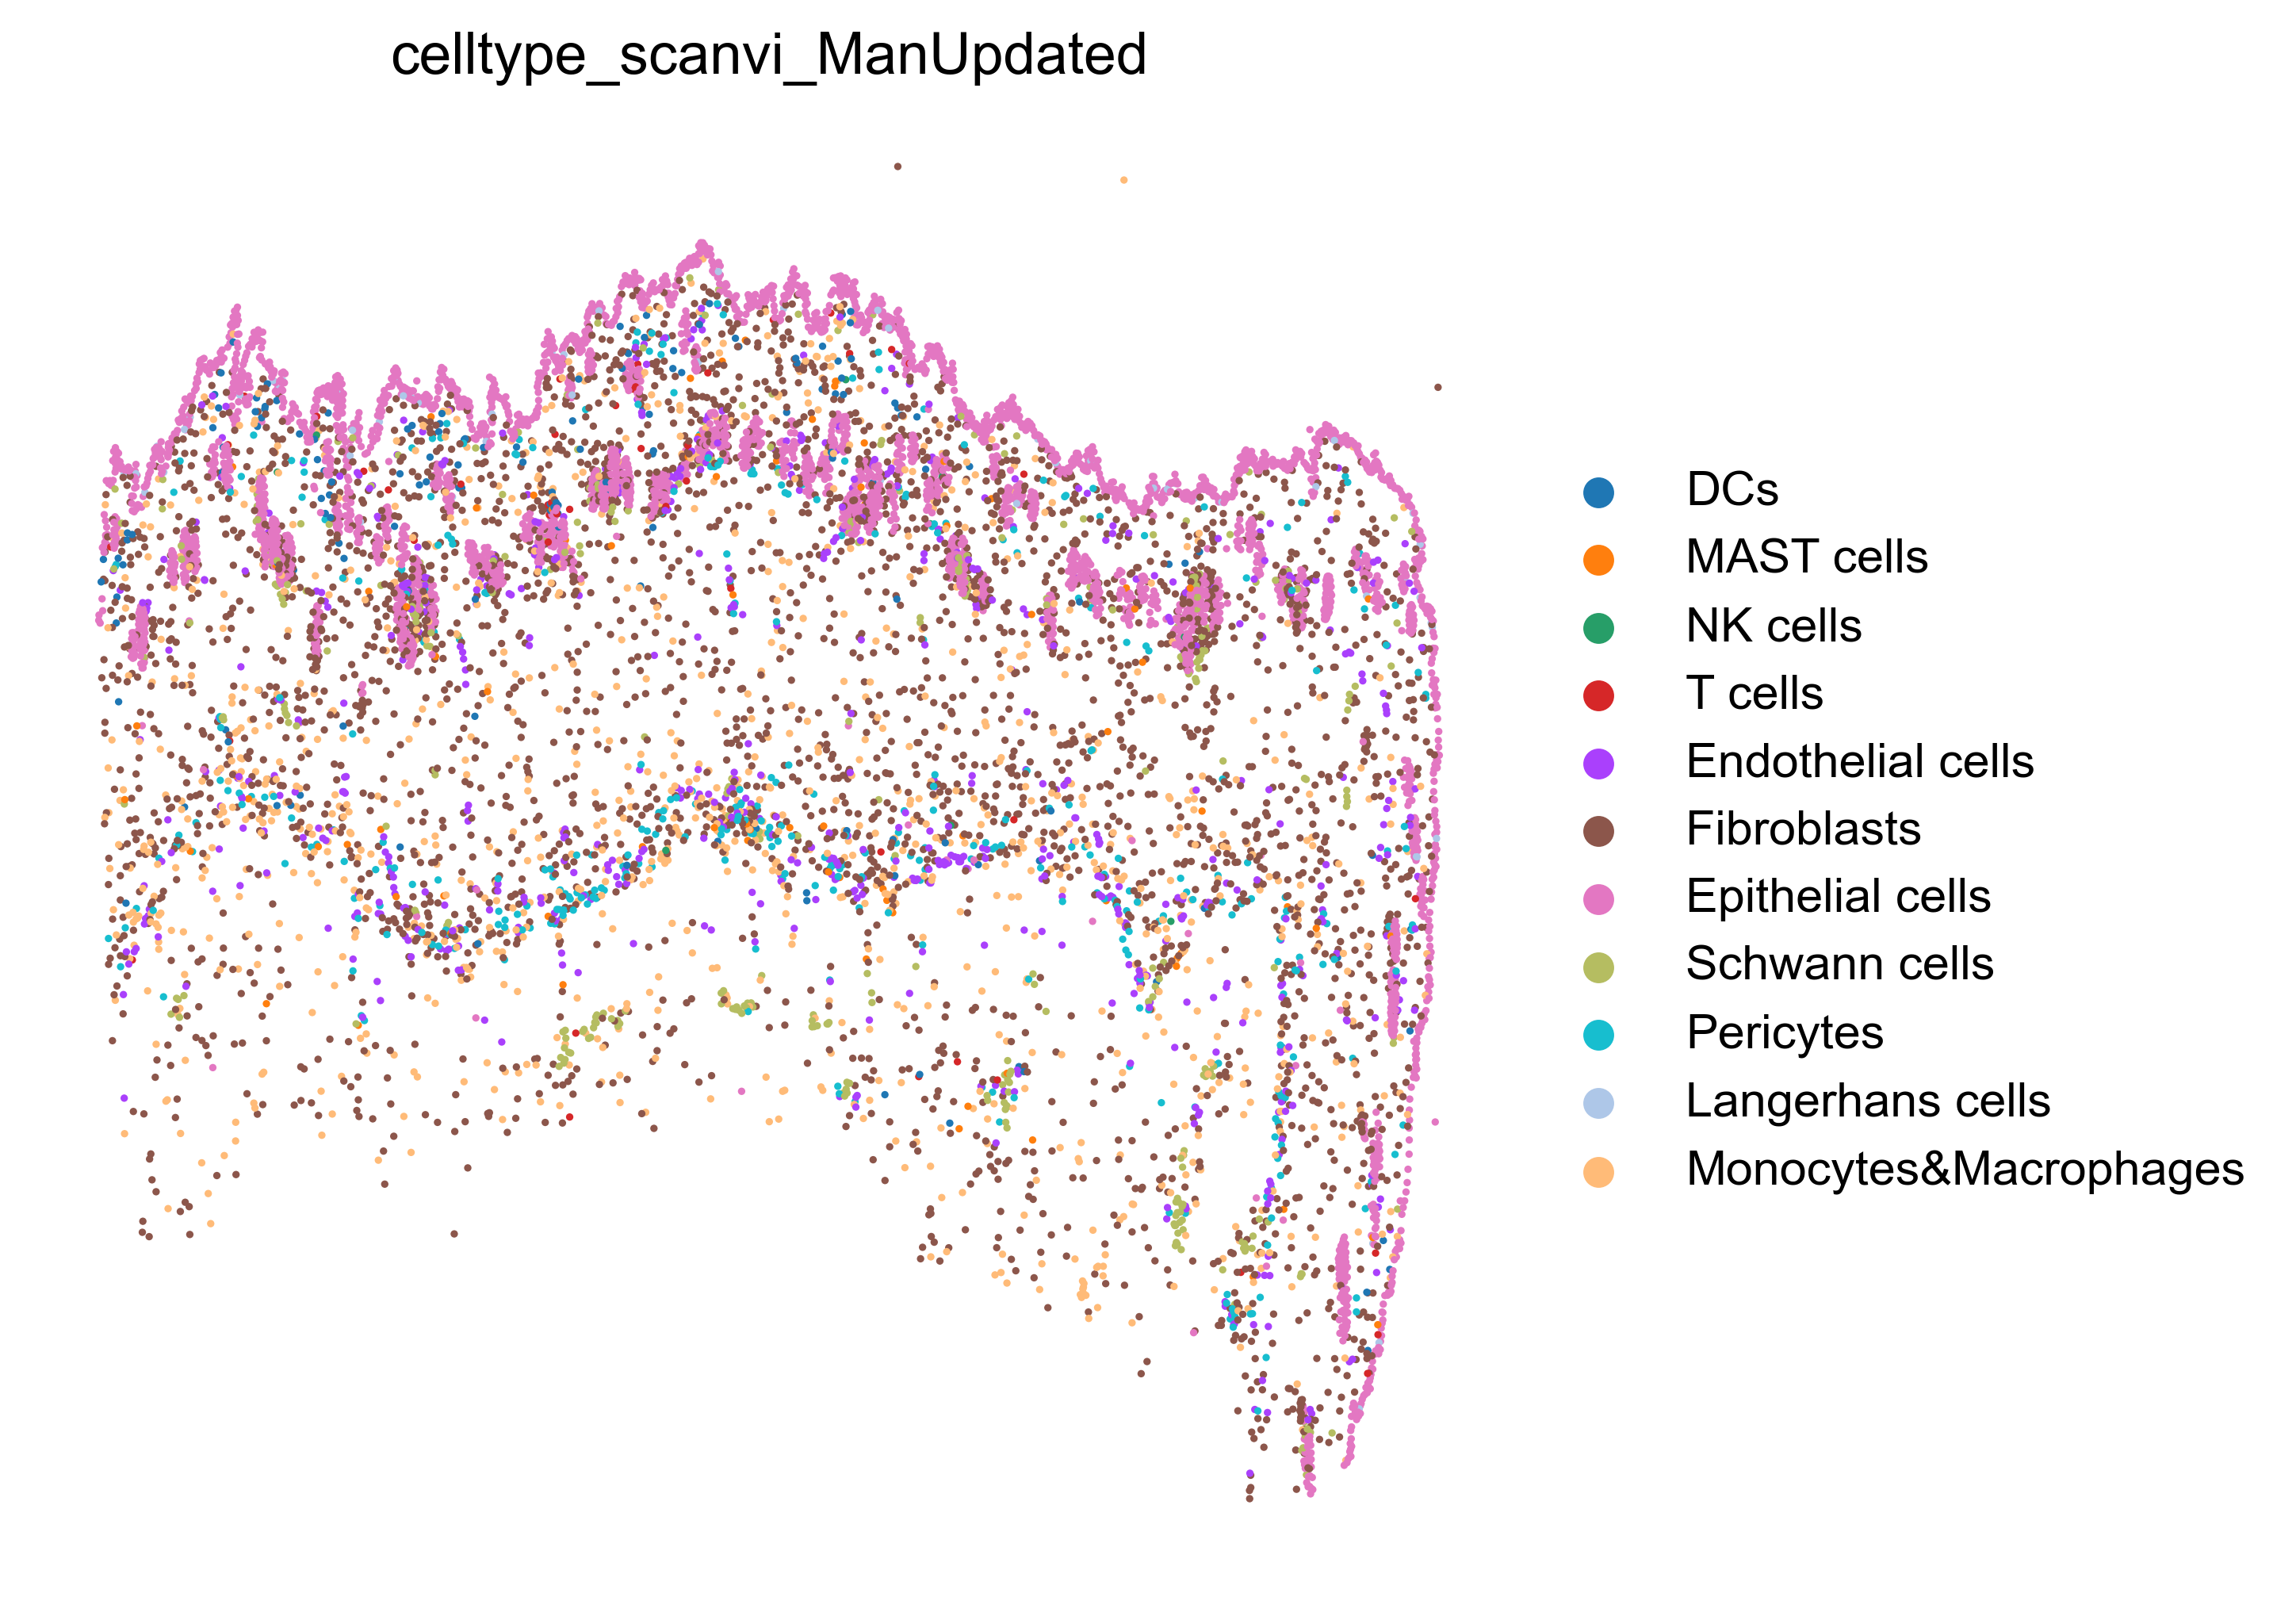

In [100]:
sc.pl.embedding(adata[adata.obs['sample_id'].isin(['sample16'])], basis='spatial', 
    color=['celltype_scanvi_ManUpdated'], 
    frameon=False
)

In [ ]:
# spacetravlr collect-interactions --run-toml /ix/djishnu/shared/djishnu_kor11/sample12/spacetravlr_run_repro.toml
# spacetravlr collect-interactions --run-toml /ix/djishnu/shared/djishnu_kor11/sample15/spacetravlr_run_repro.toml 
# spacetravlr collect-interactions --run-toml /ix/djishnu/shared/djishnu_kor11/sample16/spacetravlr_run_repro.toml 

In [109]:
basedir = '/ix/djishnu/shared/djishnu_kor11'

In [102]:
sample2condition = {
    "sample12": "Topical capsaicin 1",
    "sample15": "Compound 4880",
    "sample16": "Untreated",
}

In [ ]:
dfs = []
for i in ['12', '15', '16']:
    _df = pd.read_feather(
        basedir+f'/sample{i}/plucked_feathers.feather'
    )
    _df['condition'] = sample2condition[f'sample{i}']
    _df['sample_id'] = f'sample{i}'
    dfs.append(_df)

In [ ]:
betas = pd.concat(dfs)

In [104]:
# betas = pd.read_feather('/Volumes/SSD/all_conditions.feather')

In [111]:
activated_mast_markers_mouse = [
    'Alox5', 'Ccl2', 'Cd69', 'Egr1', 'Egr2', 
    'Hdc', 'Icam1', 'Tnf', 'Tnfrsf9',  
    'Vegfa'
]

In [106]:
all_celltypes = sorted(adata.obs['cell_type'].unique())
ct_palette = dict(zip(all_celltypes, [
    "#688bcd", "#6ab74c", "#7560cc", "#baaa45", "#bb6ac0",
    "#627b37", "#d04188", "#4db598", "#cd4b3e", "#c1687c", "#c57f40"
]))

In [107]:
sample2condition

{'sample12': 'Topical capsaicin 1',
 'sample15': 'Compound 4880',
 'sample16': 'Untreated'}

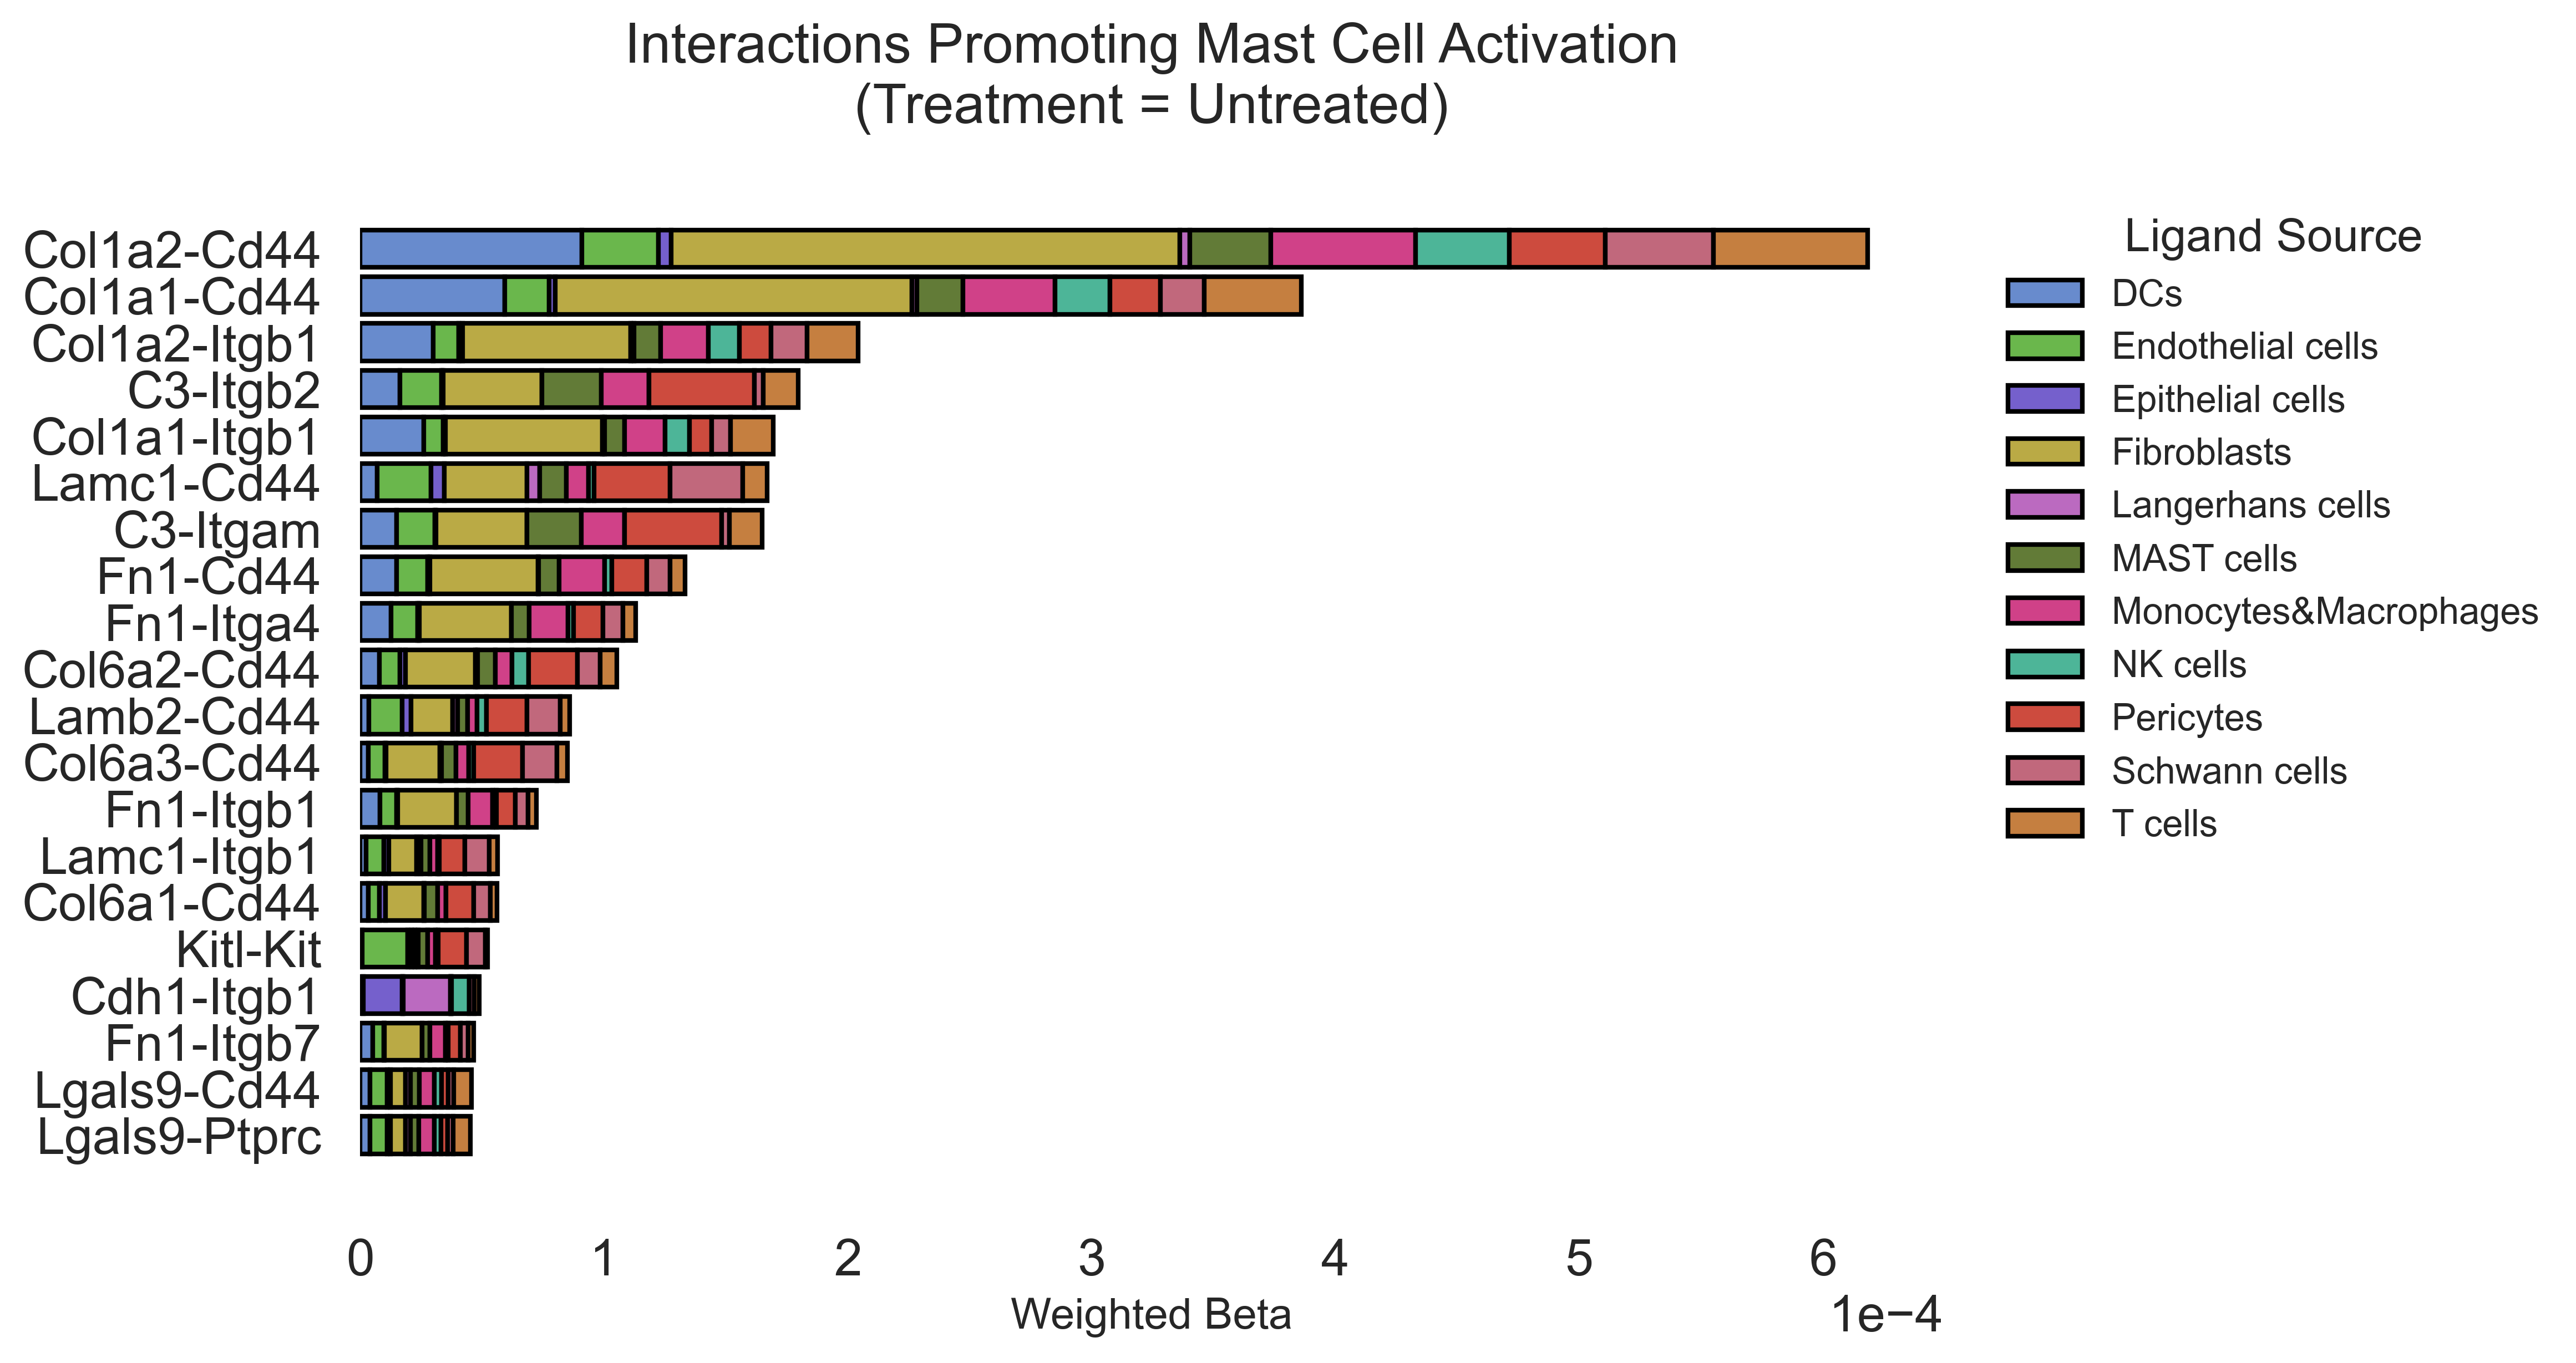

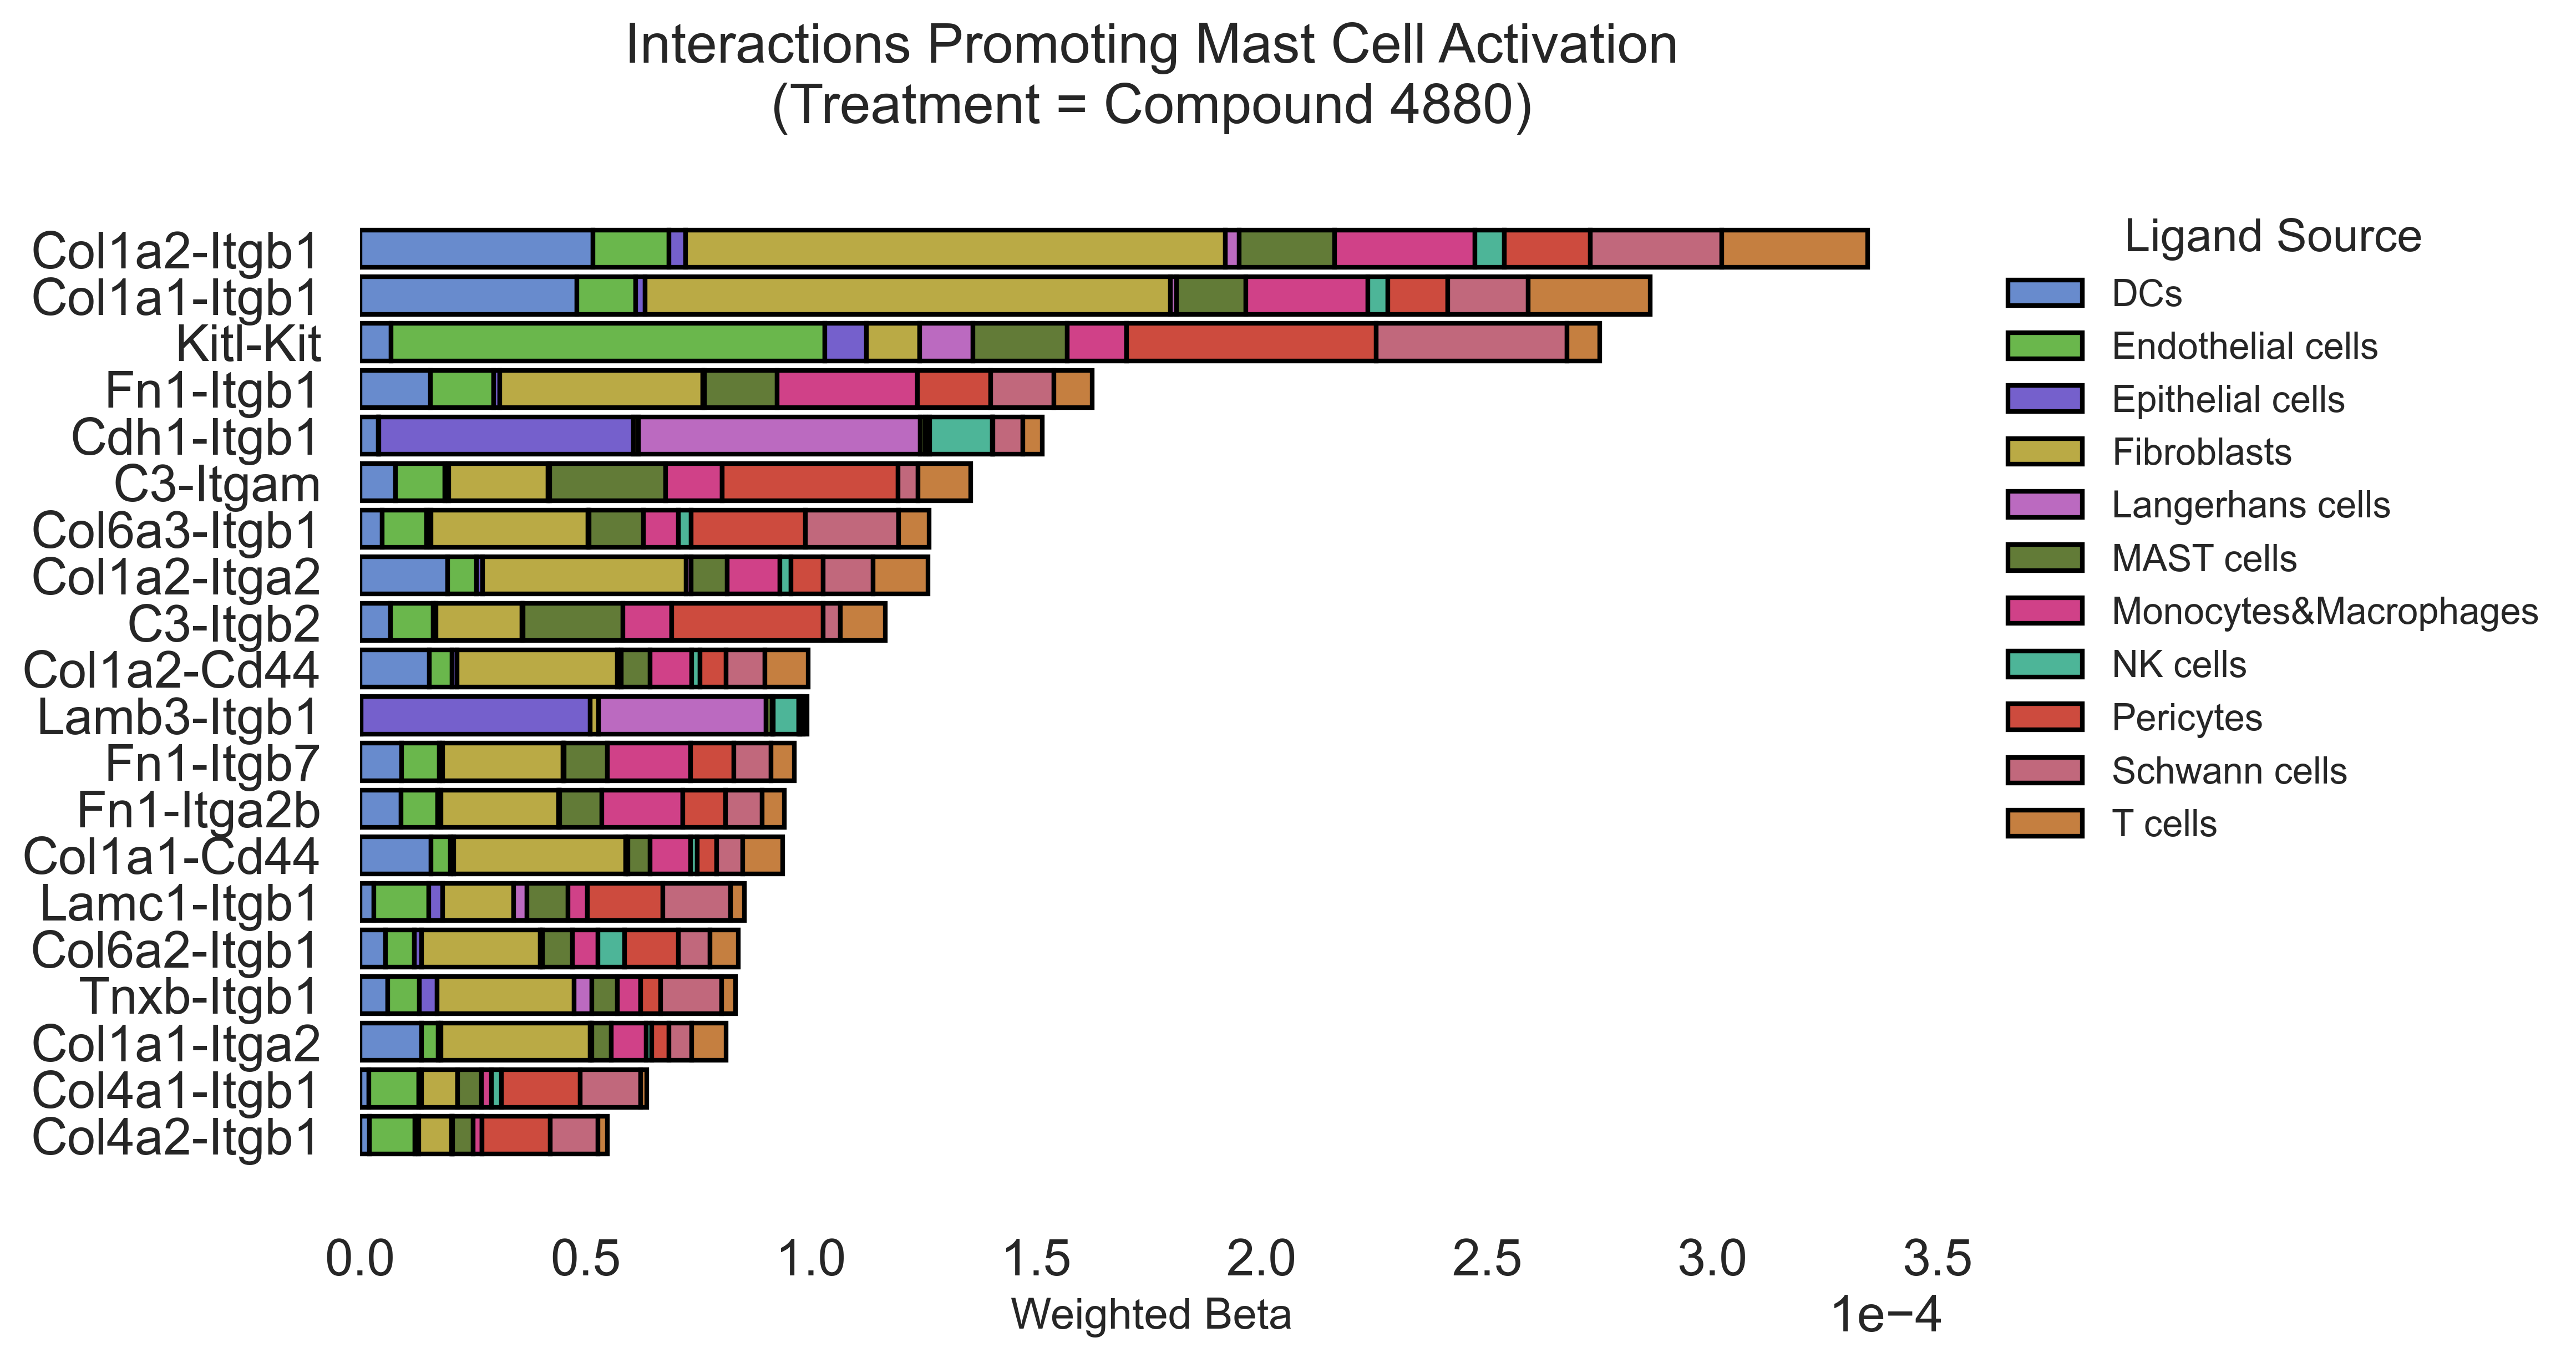

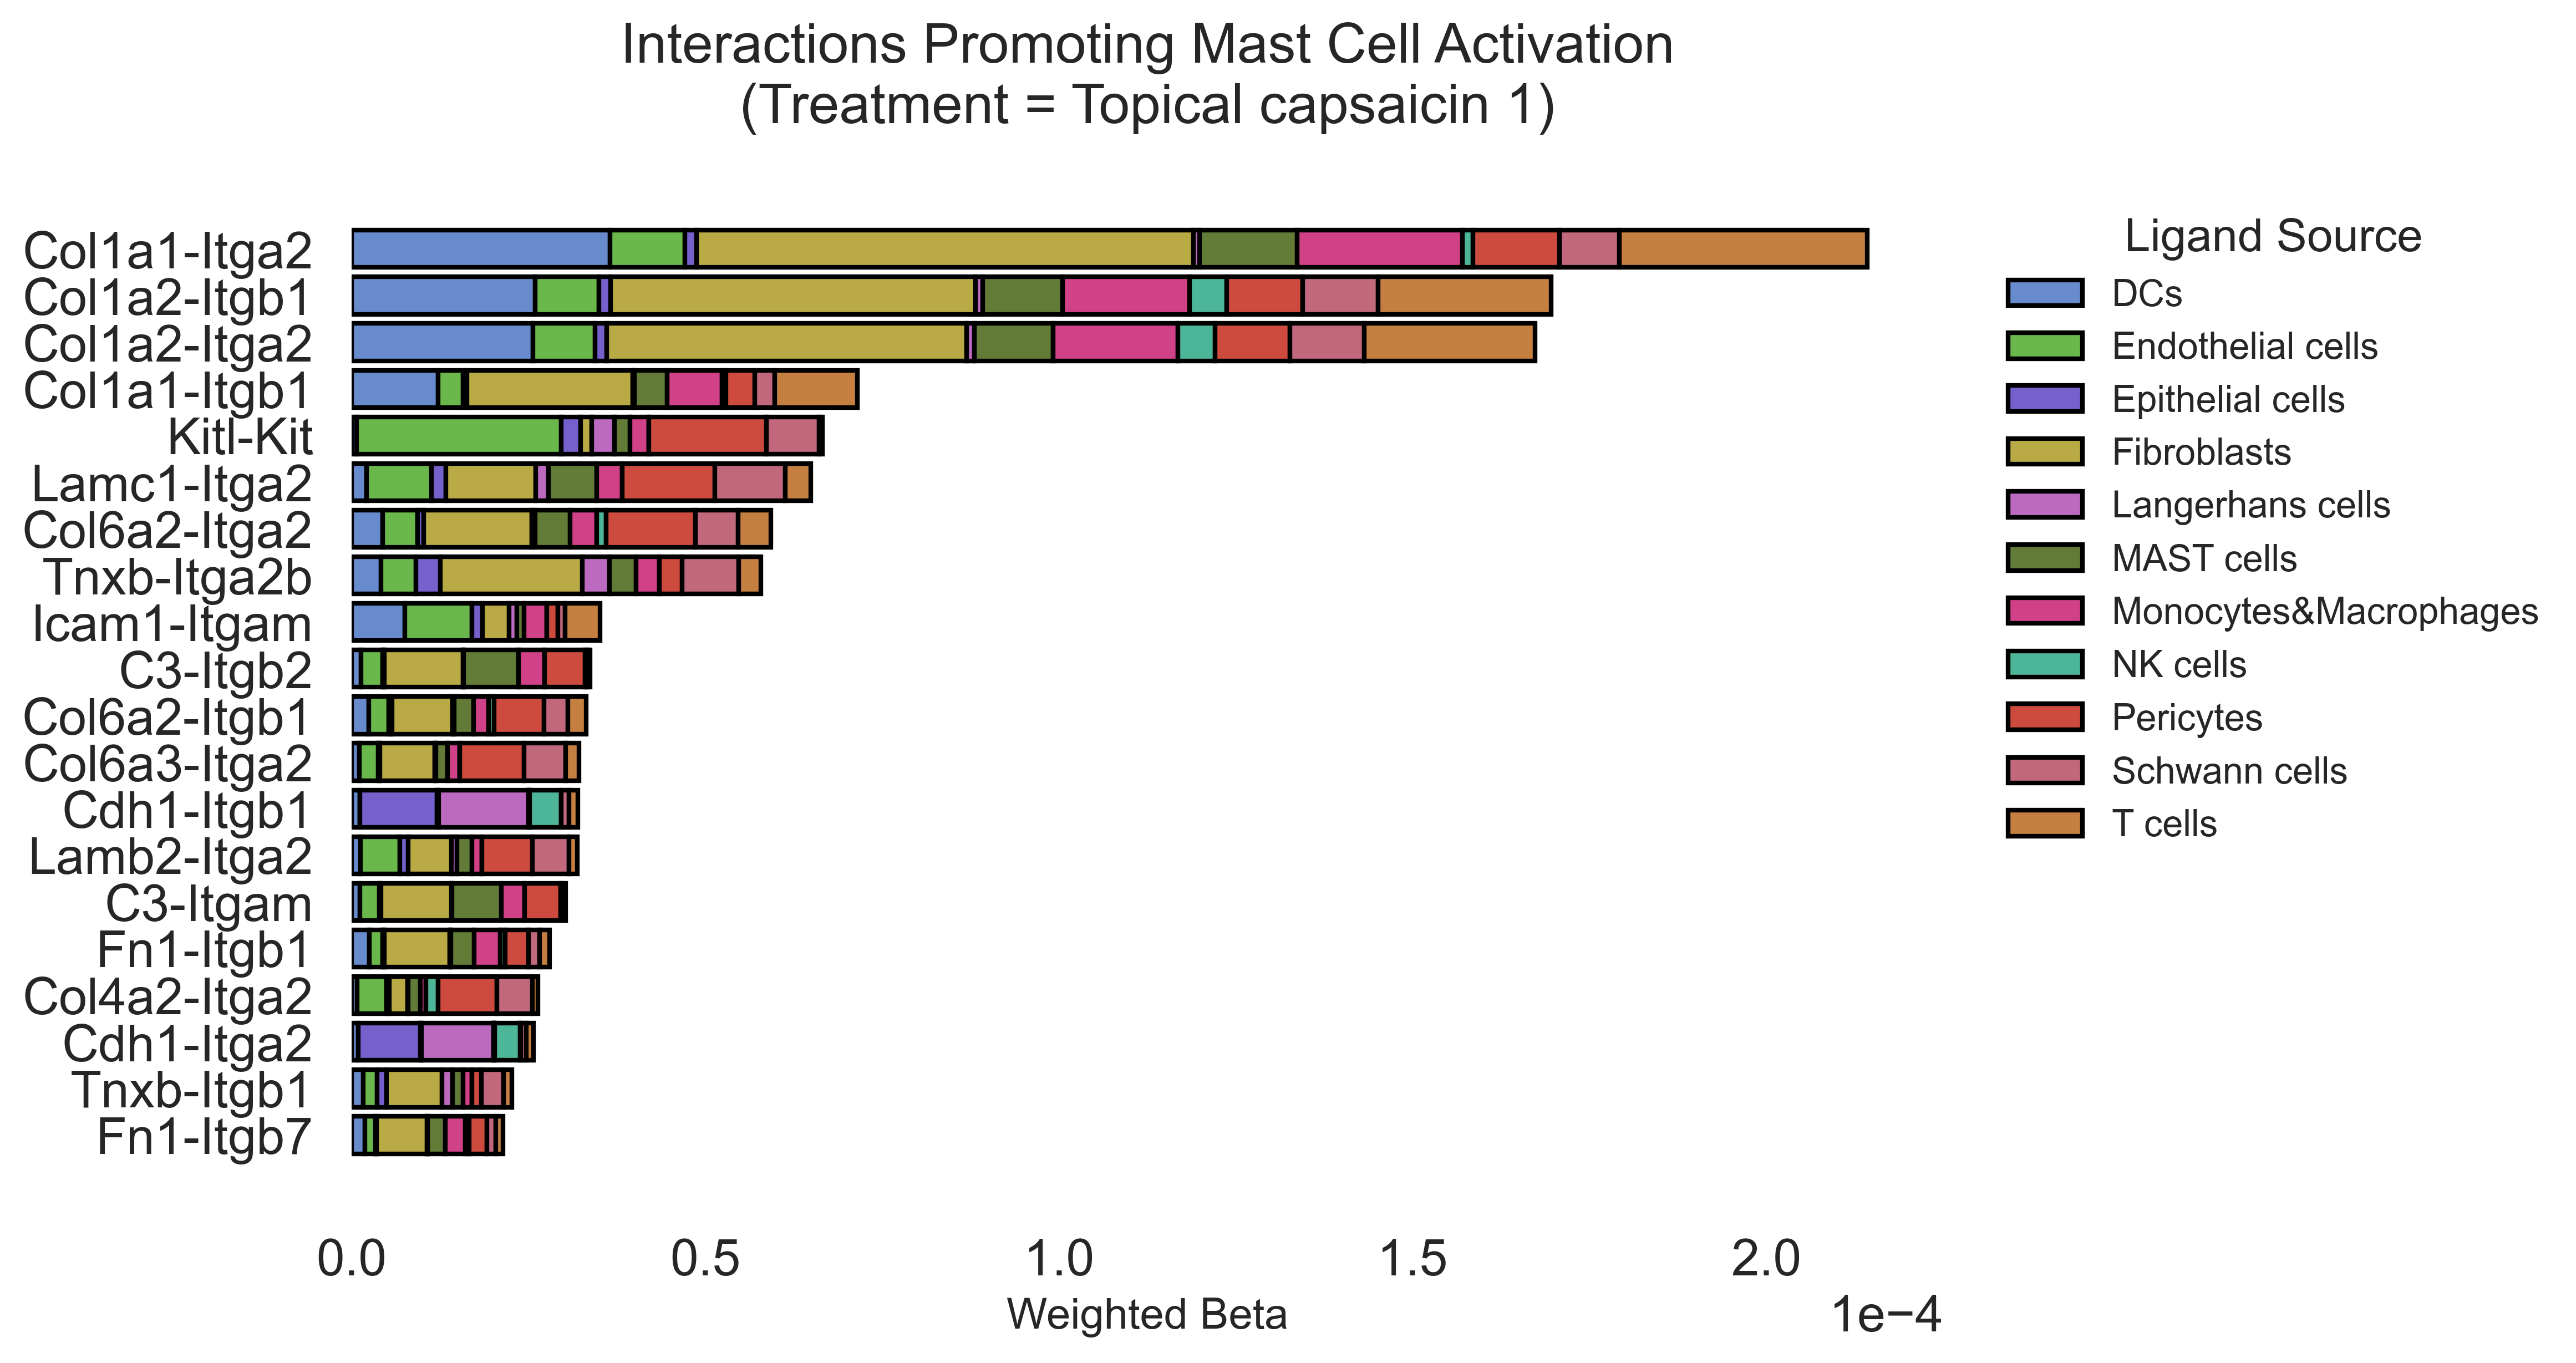

In [ ]:
lr_dict = {}

for sample in ['sample16', 'sample15', 'sample12']:
    
    expr_all = adata.to_df(layer='imputed_count')
    
    df = betas.query(
    'target_gene in @activated_mast_markers_mouse' 
    ' and interaction_type == "ligand-receptor"'
    ' and cell_type == "MAST cells"'
    ' and sample_id == @sample'
    ' and beta > 0'
    ).sort_values(
        by='beta',
        ascending=False,
        key=abs
    )
    
    mast_means = expr_all[
            (adata.obs['cell_type'] == "MAST cells") &
            (adata.obs['sample_id'] == sample)].mean()
    
    genes = df.interaction.str.split("$").str.get(1)
    receptor_expr = genes.map(mast_means)
    df['weighted_beta'] = df['beta'] * receptor_expr
    df['ligand'] = df.interaction.str.split("$").str.get(0).str.replace('beta_', '')
    df['receptor'] = df.interaction.str.split("$").str.get(1)
    df['lr_pair'] = df['ligand'] + '-' + df['receptor']
    
    top_lr = (
        df.groupby('lr_pair')['weighted_beta']
        .mean()
        .sort_values(ascending=False)
        .head(20)
    )

    lr_dict[sample] = top_lr.copy()
    
    top_ligands = df.drop_duplicates('lr_pair').set_index('lr_pair')['ligand']
    condition_mask = adata.obs['sample_id'] == sample
    ct_means = expr_all[condition_mask].groupby(
        adata.obs.loc[condition_mask, 'cell_type']).mean()
    
    rows = []
    for lr in top_lr.index:
        lig = top_ligands.get(lr, None)
        if lig is None or lig not in ct_means.columns:
            continue
        lig_by_ct = ct_means[lig]
        total_lig = lig_by_ct.sum()
        if total_lig == 0:
            continue
        fractions = lig_by_ct / total_lig
        wb = top_lr[lr]
        for ct, frac in fractions.items():
            rows.append({
                'lr_pair': lr,
                'cell_type': ct,
                'value': wb * frac
            })
    
    stacked_df = pd.DataFrame(rows)
    pivot = stacked_df.pivot_table(
        index='lr_pair', columns='cell_type',
        values='value', fill_value=0
    )
    
    pivot = pivot.reindex(top_lr.index[::-1]).fillna(0)
    pivot = pivot.loc[:, pivot.sum(axis=0) > 0]
    celltypes = pivot.columns.tolist()
    sns.set_theme(style="white", context="talk")
    
    fig, ax = plt.subplots(figsize=(12, 6.5), dpi=200)
    left = np.zeros(len(pivot))
    
    for ct in celltypes:
        ax.barh(
            pivot.index,
            pivot[ct],
            left=left,
            color=ct_palette[ct],
            edgecolor='black',
            linewidth=1.5,
            label=ct
        )
        left += pivot[ct].values
    
    ax.set_title(f"Interactions Promoting Mast Cell Activation\n(Treatment = {sample2condition[sample]})", pad=20)
    ax.set_xlabel("Weighted Beta", fontsize=14)
    ax.set_ylabel("")
    ax.legend(
        title="Ligand Source", 
        bbox_to_anchor=(1.02, 1),
        loc='upper left', 
        fontsize=12, 
        title_fontsize=15,
        edgecolor='white'
    )

    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    sns.despine(ax=ax, left=True, bottom=True)
    plt.tight_layout()
    # plt.savefig(f'{sample2condition[sample]}.svg', **figure_params)
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

def find_significant_lr_shifts(series1, series2, z_threshold=1.96, ascending=False):
    """
    Compares two pandas Series of Ligand-Receptor pairs and identifies 
    statistically significant rank shifts using Z-scores.
    
    Parameters:
    - series1 (pd.Series): First input dataset (Index = LR pairs, Values = scores).
    - series2 (pd.Series): Second input dataset (Index = LR pairs, Values = scores).
    - z_threshold (float): Z-score threshold for significance (1.96 ≈ p<0.05).
    - ascending (bool): Set to True if smaller values are better (e.g., p-values). 
                        Set to False if larger values are better (e.g., interaction scores).
    """
    
    df1 = series1.reset_index()
    df1.columns = ['lr_pair', 'score']
    
    df2 = series2.reset_index()
    df2.columns = ['lr_pair', 'score']

    # 2. Rank the LR pairs 
    df1['rank1'] = df1['score'].rank(ascending=ascending, method='min')
    df2['rank2'] = df2['score'].rank(ascending=ascending, method='min')

    merged = pd.merge(
        df1[['lr_pair', 'rank1']],
        df2[['lr_pair', 'rank2']], 
        on='lr_pair', how='outer'
    )

    max_rank = max(df1['rank1'].max(), df2['rank2'].max()) + 1
    merged.fillna(max_rank, inplace=True)

    merged['rank_diff'] = merged['rank2'] - merged['rank1']
    merged['abs_rank_diff'] = merged['rank_diff'].abs()

    mean_diff = merged['rank_diff'].mean()
    std_diff = merged['rank_diff'].std()

    if std_diff > 0:
        merged['z_score'] = (merged['rank_diff'] - mean_diff) / std_diff
        merged['is_significant'] = merged['z_score'].abs() > z_threshold
    else:
        merged['z_score'] = 0.0
        merged['is_significant'] = False

    result_df = merged.sort_values(
        by='abs_rank_diff', ascending=False).reset_index(drop=True)
    
    return result_df


In [115]:
find_significant_lr_shifts(
    lr_dict['sample12'], 
    lr_dict['sample16'], 
    z_threshold=1.0, 
    ascending=False
)

,lr_pair,rank1,rank2,rank_diff,abs_rank_diff,z_score,is_significant
0,Col1a1-Itga2,1.0,21.0,20.0,20.0,1.840646,True
1,Col1a2-Cd44,21.0,1.0,-20.0,20.0,-1.840646,True
2,Col1a1-Cd44,21.0,2.0,-19.0,19.0,-1.748614,True
3,Col1a2-Itga2,3.0,21.0,18.0,18.0,1.656582,True
4,Lamc1-Itga2,6.0,21.0,15.0,15.0,1.380485,True
5,Lamc1-Cd44,21.0,6.0,-15.0,15.0,-1.380485,True
6,Col6a2-Itga2,7.0,21.0,14.0,14.0,1.288452,True
7,Tnxb-Itga2b,8.0,21.0,13.0,13.0,1.196420,True
8,Fn1-Cd44,21.0,8.0,-13.0,13.0,-1.196420,True
9,Icam1-Itgam,9.0,21.0,12.0,12.0,1.104388,True


In [127]:
COLORS = {
    "Down": "#3D6FA8",      # toward sample12 (negative rank_diff)
    "Up": "#D65F5F",        # toward sample16 (positive rank_diff)
    "Not Sig": "#C8C8C8",
}
EDGE_COLOR = "#3a3a3a"
LABEL_EDGE = "#666666"
CONNECTOR_COLOR = "#555555"

FIGURE_PARAMS = {
    "dpi": 300,
    "bbox_inches": "tight",
    "format": "svg",
    "transparent": True,
}


def apply_style() -> None:
    plt.rcParams.update(
        {
            "text.usetex": False,
            "svg.fonttype": "none",
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
            "font.size": 11,
            "axes.labelsize": 12,
            "axes.labelweight": "medium",
            "axes.linewidth": 1.0,
            "axes.edgecolor": "#333333",
            "xtick.color": "#444444",
            "ytick.color": "#444444",
            "figure.facecolor": "none",
            "axes.facecolor": "white",
            "savefig.transparent": True,
        }
    )


def prepare_lr_shift_volcano(
    shifts: pd.DataFrame,
    *,
    sample_a: str = "sample12",
    sample_b: str = "sample16",
) -> pd.DataFrame:
    """Map find_significant_lr_shifts() output to volcano columns."""
    df = shifts.copy()
    df["gene"] = df["lr_pair"].astype(str)
    df["logfc"] = df["rank_diff"]  # rank_b - rank_a

    z = df["z_score"].fillna(0.0).to_numpy()
    p_two = 2.0 * (1.0 - norm.cdf(np.abs(z)))
    df["pvalue"] = np.clip(p_two, np.finfo(float).tiny, 1.0)
    df["neglog10_p"] = -np.log10(df["pvalue"])

    return df


def classify_lr_shifts(
    df: pd.DataFrame,
    *,
    use_is_significant: bool = True,
    rank_threshold: float = 1.0,
    label_up: str = "Up",
    label_down: str = "Down",
) -> pd.DataFrame:
    out = df.copy()
    if use_is_significant and "is_significant" in out.columns:
        sig = out["is_significant"] & (out["abs_rank_diff"] >= rank_threshold)
    else:
        sig = out["abs_rank_diff"] >= rank_threshold

    out["status"] = np.where(
        sig & (out["logfc"] > 0),
        label_up,
        np.where(sig & (out["logfc"] < 0), label_down, "Not Sig"),
    )
    return out


def label_start_position(x, y, xlim, ylim):
    xspan = xlim[1] - xlim[0]
    yspan = ylim[1] - ylim[0]
    dx = 0.045 * xspan * (1.0 if x >= 0 else -1.0)
    if abs(x) < 0.05:
        dx = 0.045 * xspan
    dy = 0.008 * yspan
    tx = float(np.clip(x + dx, xlim[0] + 0.01 * xspan, xlim[1] - 0.01 * xspan))
    ty = float(np.clip(y + dy, ylim[0] + 0.01 * yspan, ylim[1] - 0.01 * yspan))
    return tx, ty


def draw_label_connectors(ax, annotations, *, length_frac: float = 0.88):
    for ann in annotations:
        x0, y0 = ann.xy
        xt, yt = ann.xyann
        xe = x0 + length_frac * (xt - x0)
        ye = y0 + length_frac * (yt - y0)
        ax.plot(
            [x0, xe],
            [y0, ye],
            color=CONNECTOR_COLOR,
            lw=0.65,
            alpha=0.75,
            zorder=4,
            clip_on=False,
            solid_capstyle="round",
        )


def pick_labels_lr(df: pd.DataFrame, *, top_up: int = 5, top_down: int = 5) -> pd.DataFrame:
    """Top positive / negative rank_diff among significant rows."""
    if "is_significant" in df.columns:
        pool = df[df["is_significant"]]
    else:
        pool = df[df["status"] != "Not Sig"]
    if pool.empty:
        return pool

    parts = []
    up = pool[pool["logfc"] > 0]
    down = pool[pool["logfc"] < 0]
    if not up.empty:
        parts.append(up.nlargest(min(top_up, len(up)), "logfc"))
    if not down.empty:
        parts.append(down.nsmallest(min(top_down, len(down)), "logfc"))
    if not parts:
        return pool.iloc[0:0]
    return pd.concat(parts).drop_duplicates("gene")

def plot_lr_shift_volcano(
    df: pd.DataFrame,
    *,
    sample_a: str = "sample12",
    sample_b: str = "sample16",
    output: str | Path | None = "/tmp/xenium_skin_lr_volcano.svg",
    show: bool = True,
    figsize=(7.5, 6.5),
    top_up: int = 5,
    top_down: int = 5,
    point_size: float = 72,
    label_up: str | None = None,
    label_down: str | None = None,
) -> tuple[plt.Figure, pd.DataFrame]:
    apply_style()
    label_up = label_up or f"Higher in {sample_b}"
    label_down = label_down or f"Higher in {sample_a}"

    # Remap status labels for legend readability
    status_map = {"Up": label_up, "Down": label_down, "Not Sig": "Not Sig"}
    plot_df = df.copy()
    plot_df["plot_status"] = plot_df["status"].map(status_map).fillna(plot_df["status"])

    fig, ax = plt.subplots(figsize=figsize, dpi=200)
    fig.patch.set_alpha(0.0)

    pad_x = max(1.0, 0.15 * plot_df["logfc"].abs().max())
    pad_y = max(0.5, 0.08 * plot_df["neglog10_p"].max())
    xlim = (plot_df["logfc"].min() - pad_x, plot_df["logfc"].max() + pad_x)
    ymax = plot_df["neglog10_p"].max() + pad_y
    ylim = (-0.045 * ymax, ymax)

    legend_order = [
        ("Not Sig", COLORS["Not Sig"], 0.55, 1),
        (label_down, COLORS["Down"], 0.92, 2),
        (label_up, COLORS["Up"], 0.92, 3),
    ]
    for leg_label, color, alpha, z in legend_order:
        if leg_label == "Not Sig":
            sub = plot_df[plot_df["status"] == "Not Sig"]
        elif leg_label == label_down:
            sub = plot_df[plot_df["status"] == "Down"]
        else:
            sub = plot_df[plot_df["status"] == "Up"]

        ax.scatter(
            sub["logfc"],
            sub["neglog10_p"],
            c=color,
            s=point_size,
            alpha=alpha,
            edgecolors=EDGE_COLOR,
            linewidths=1,
            label=leg_label,
            zorder=z,
            rasterized=output is not None and str(output).lower().endswith(".png"),
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    label_bbox = dict(
        boxstyle="round,pad=0.55",
        facecolor="white",
        edgecolor=LABEL_EDGE,
        linewidth=0.5,
        alpha=0.95,
    )

    label_df = pick_labels_lr(df, top_up=top_up, top_down=top_down)
    annotations = []
    for _, row in label_df.iterrows():
        x, y = row["logfc"], row["neglog10_p"]
        tx, ty = label_start_position(x, y, xlim, ylim)
        ann = ax.annotate(
            row["gene"],
            xy=(x, y),
            xytext=(tx, ty),
            textcoords="data",
            fontsize=9.5,
            fontstyle="italic",
            ha="center",
            va="center",
            color="#222222",
            bbox=label_bbox,
            zorder=6,
        )
        annotations.append(ann)

    if annotations:
        adjust_text(
            annotations,
            ax=ax,
            x=plot_df["logfc"].to_numpy(),
            y=plot_df["neglog10_p"].to_numpy(),
            expand_points=(1.15, 1.15),
            expand_text=(4.02, 4.02),
            force_text=(0.15, 0.25),
            force_points=(0.2, 0.3),
            # only_move={"text": "xy"},
            lim=500,
        )
        draw_label_connectors(ax, annotations)

    ax.set_xlabel(f"Rank difference")
    ax.set_ylabel(r"$-$log$_{10}$(two-tailed $p$ from $z$)")
    # ax.legend(
    #     frameon=True,
    #     fancybox=True,
    #     framealpha=0.95,
    #     ncol=3,
    #     edgecolor=None,
    #     loc="upper left",
    #     bbox_to_anchor=(1.01, 1.0),
    #     borderaxespad=0,
    #     markerscale=1.1,
    #     handletextpad=0.6,
    # )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=4, width=0.8)

    if output is not None:
        fig.savefig(output, **FIGURE_PARAMS)
        print(f"Wrote {output}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, label_df

In [116]:
sample2condition

{'sample12': 'Topical capsaicin 1',
 'sample15': 'Compound 4880',
 'sample16': 'Untreated'}

8 [ 0.33561706 -0.1217624 ]
9 [0.60937242 0.03739005]
12 [ 0.77171276 -0.59353661]
13 [0.54127068 0.21452967]
1 [0.24923849 0.09740865]
2 [-0.15533532 -0.69486597]
Wrote /tmp/volcano_sample15_sample16.svg


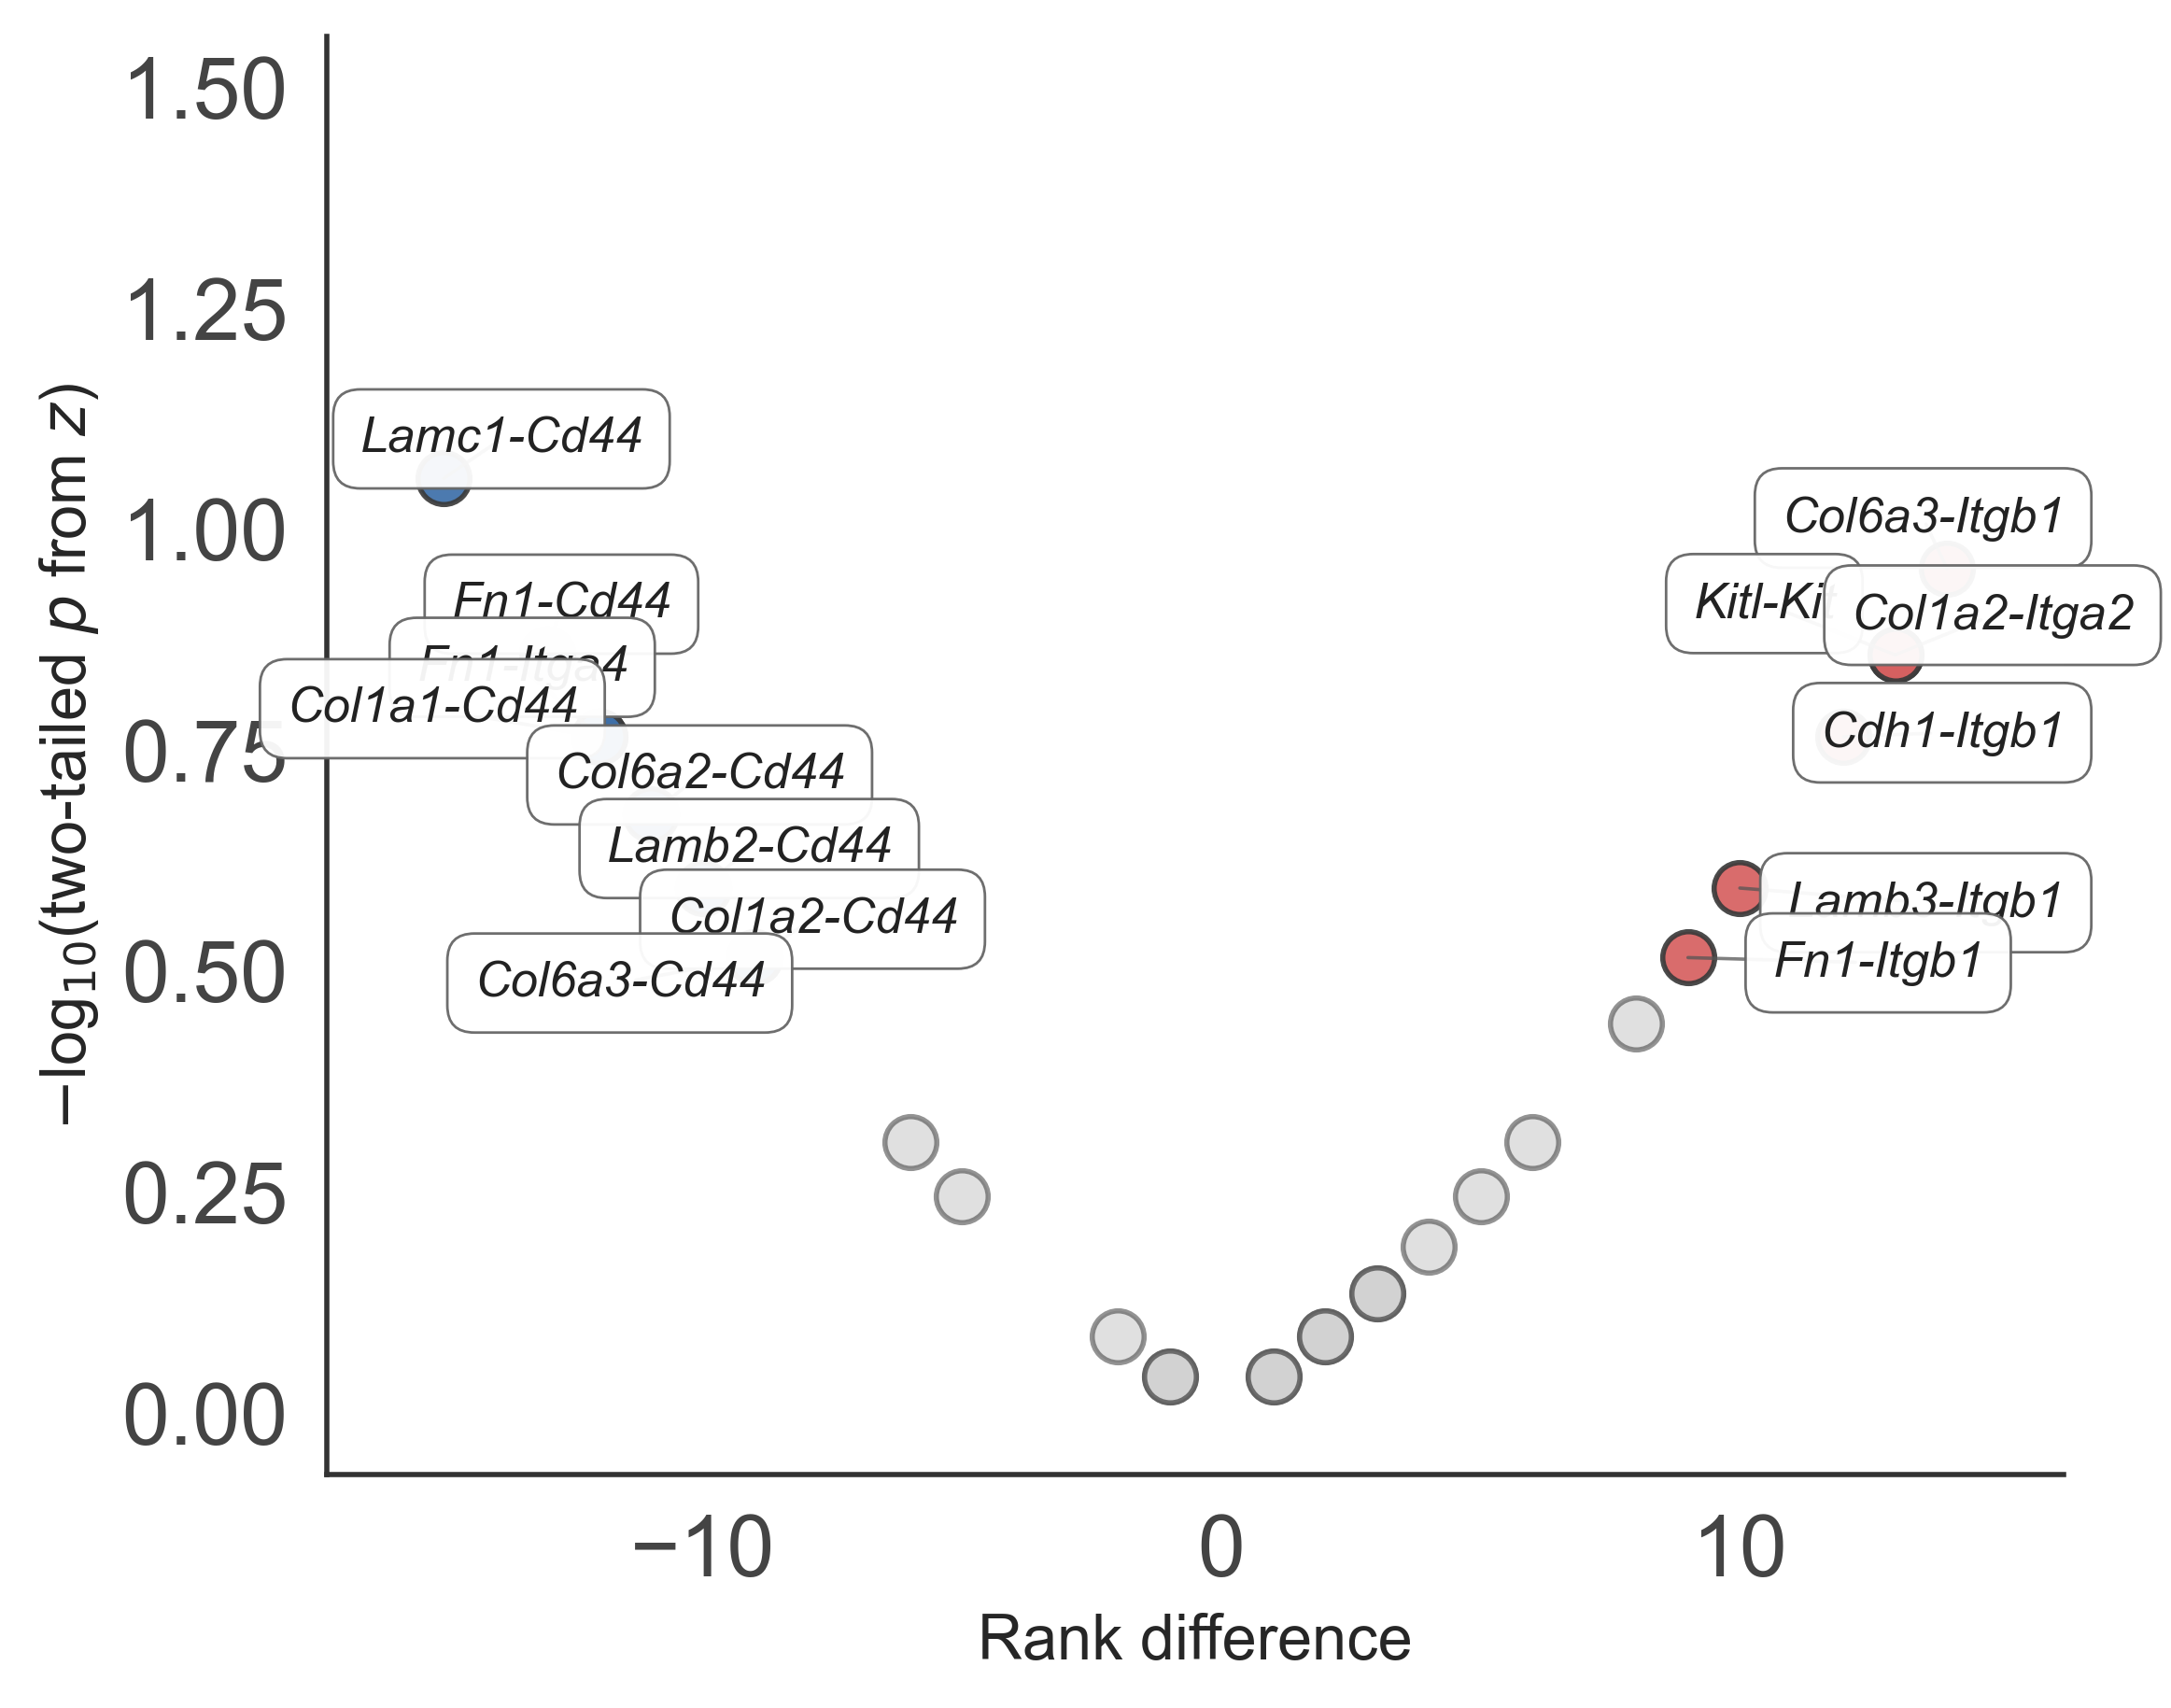

In [128]:
SAMPLE_A = "sample15"
SAMPLE_B = "sample16"
Z_THRESHOLD = 1.0
RANK_THRESHOLD = 1.0

shifts = find_significant_lr_shifts(
    lr_dict[SAMPLE_A],
    lr_dict[SAMPLE_B],
    z_threshold=Z_THRESHOLD,
    ascending=False,
)

df = prepare_lr_shift_volcano(shifts, sample_a=SAMPLE_A, sample_b=SAMPLE_B)
df = classify_lr_shifts(
    df,
    use_is_significant=True,
    rank_threshold=RANK_THRESHOLD,
)

fig, labeled = plot_lr_shift_volcano(
    df,
    sample_a=SAMPLE_B,
    sample_b=SAMPLE_A,
    point_size=100,
    output=f"/tmp/volcano_{SAMPLE_A}_{SAMPLE_B}.svg",
    show=True,
    top_up=10,
    figsize=(6, 5),
    top_down=10,
)